In [110]:
import os 
import sys
module_path = "compiled_python_modules/"
sys.path.append(module_path)

import numpy as np
import matplotlib.pyplot as plt

from numba import njit

from general_python_module import *

### Load relevant variables

In [111]:
MJ_tab_6 = load_MJ_tab_6() # conventional order of amino acids given by num_to_letter_map variable
hamiltonian_walks_contacts=load_hamiltonian_walks_contacts()
hamiltonian_walks_max_abs_GE=load_hamiltonian_walks_max_abs_GE()
hamiltonian_walks_i1_i2=load_hamiltonian_walks_maGE_loop_i1_i2()
hamiltonian_walks_maGE_thread_is_N=load_hamiltonian_walks_maGE_thread_is_N()


In [112]:
path_with_dicts="data/wl_results/struct_006222/seq_ASDMCICDCGWRGSRADCFFRLGMWFM"
list_of_dict=[v for v in os.listdir(path_with_dicts) if 'results_dict' in v]


all_final_raw_ln_g_E=[]
all_bin_has_been_visited=[]

all_saved_conformations=[]
all_saved_conformations_contacts=[]
all_saved_conformations_n_native_contacts=[]

required_flatness_checks=18
for dict_fname in list_of_dict:
    now_dict=np.load(os.path.join(path_with_dicts,dict_fname),\
    allow_pickle=True,).item()
    list_of_repetitions_done=[l for l in now_dict.keys() if isinstance(l, int)]
    for i_repetition in list_of_repetitions_done:
        history_flat_ln_g_E=now_dict[i_repetition]['history_flat_ln_g_E']
        bin_has_been_visited=now_dict[i_repetition]['bin_has_been_visited']
        inds_non_zeros=np.argwhere(history_flat_ln_g_E.sum(axis=0)>0)[:,0]
        if len(inds_non_zeros)>required_flatness_checks:
            final_ln_g_E=history_flat_ln_g_E[:,inds_non_zeros[-1]]
            all_final_raw_ln_g_E.append(final_ln_g_E)
            all_bin_has_been_visited.append(bin_has_been_visited)
            all_saved_conformations.append(
                now_dict[i_repetition]['saved_conformations']
            )
            all_saved_conformations_contacts.append(
                now_dict[i_repetition]['saved_conformations_contacts']
            )
            all_saved_conformations_n_native_contacts.append(
                now_dict[i_repetition]['saved_conformations_n_native_contacts']
            )

            
    energy_bin_centers=now_dict['energy_bin_centers']
    energy_bin_measures=now_dict['energy_bin_measures']

    # assuming leftmost bin contains only the native state
    for ii in range(len(all_final_raw_ln_g_E)):
        all_final_raw_ln_g_E[ii]=all_final_raw_ln_g_E[ii]-all_final_raw_ln_g_E[ii][bin_has_been_visited.astype(np.bool_)][0]

    all_final_raw_ln_g_E=np.array(all_final_raw_ln_g_E)
    all_final_g_E = np.exp(all_final_raw_ln_g_E)

    mean_g_E=all_final_g_E.mean(axis=0)
    std_g_E=all_final_g_E.std(axis=0)

all_saved_conformations=np.array(all_saved_conformations)
all_saved_conformations_contacts=np.array(all_saved_conformations_contacts)
all_saved_conformations_n_native_contacts=np.array(all_saved_conformations_n_native_contacts)

Text(0, 0.5, 'number of structures')

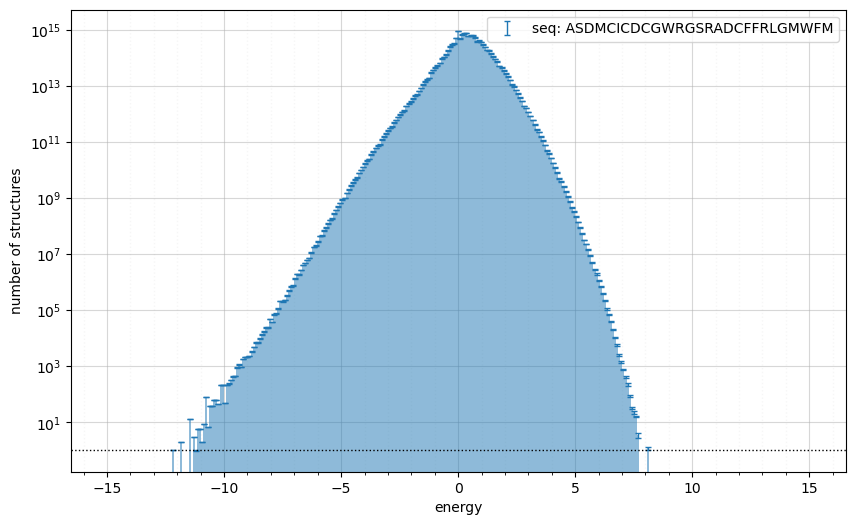

In [113]:
fig,ax=plt.subplots(figsize=(10,6))
ax.grid(alpha=0.5, which='both')
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=1)
ax.minorticks_on()
ax.set_axisbelow(True)

# ax.errorbar(energy_bin_centers, mean_g_E, 
#         yerr=std_g_E, fmt='+', markersize=5.0, markeredgewidth=1.0, capsize=4.0, 
#         elinewidth=1.0,errorevery=1,label=f"seq: {path_with_dicts.split('seq_')[1]:}")

ax.errorbar(energy_bin_centers, mean_g_E, 
        yerr=std_g_E, fmt='_', markersize=0.0, markeredgewidth=1.0, capsize=2.0, 
        elinewidth=1.0,errorevery=1,label=f"seq: {path_with_dicts.split('seq_')[1]:}")

# ax.step(energy_bin_centers, mean_g_E, where='mid')
ax.bar(energy_bin_centers, mean_g_E, width=energy_bin_measures, 
       align='center', alpha=0.5)

ax.axhline(1,c='k',lw=1.0,ls=':')
ax.legend()
ax.set_yscale('log')
ax.set_xlabel('energy')
ax.set_ylabel('number of structures')


In [114]:
Ts=np.linspace(0.01,0.4,5000)

betas=np.reshape(Ts**-1,(1,-1))
mean_g_E=np.reshape(all_final_g_E.mean(axis=0),(-1,1))
std_g_E=np.reshape(all_final_g_E.std(axis=0),(-1,1))
vec_energy_bin_centers=np.reshape(energy_bin_centers,(-1,1))


F_beta=-(betas**-1)*\
    (np.log(np.sum(mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)))
U_beta=np.sum(vec_energy_bin_centers*mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)/\
    np.sum(mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)

S_beta=(U_beta-F_beta)/Ts
av_E_beta=np.sum(vec_energy_bin_centers*mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)/\
    np.sum(mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)

av_E2_beta=np.sum((vec_energy_bin_centers**2)*mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)/\
    np.sum(mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)

CV_beta=(av_E2_beta-av_E_beta**2)/Ts**2

mean_g_E=mean_g_E.flatten()
std_g_E=std_g_E.flatten()
F_beta=F_beta.flatten()
U_beta=U_beta.flatten()
S_beta=S_beta.flatten()

# possibile che qui sotto si lamenti fi overflow ma non credo sia un vero problema (è un warning, non un errore)


/var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/ipykernel_44451/1387442181.py:10: RuntimeWarning: overflow encountered in exp
  (np.log(np.sum(mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)))
/var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/ipykernel_44451/1387442181.py:10: RuntimeWarning: overflow encountered in multiply
  (np.log(np.sum(mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)))
/var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/ipykernel_44451/1387442181.py:10: RuntimeWarning: invalid value encountered in multiply
  (np.log(np.sum(mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)))
/var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/ipykernel_44451/1387442181.py:11: RuntimeWarning: overflow encountered in exp
  U_beta=np.sum(vec_energy_bin_centers*mean_g_E*np.exp(-betas*vec_energy_bin_centers),axis=0)/\
/var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/ipykernel_44451/1387442181.py:11: RuntimeWarning: overflow encountered in multiply
  U_beta=np.sum(vec_energy_

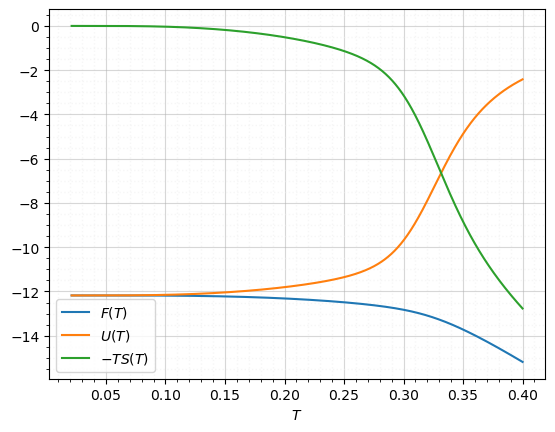

In [115]:
fig,ax=plt.subplots()
ax.grid(alpha=0.5, which='both')
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=1)
ax.minorticks_on()
ax.set_axisbelow(True)

ax.plot(Ts, F_beta,label='$F(T)$')
ax.plot(Ts, U_beta,label='$U(T)$')
ax.plot(Ts, -Ts*S_beta,label='$-TS(T)$')

ax.set_xlabel('$T$')
ax.legend()

In [116]:
n_repetitions,n_bonds,n_conformations_per_bin,n_bins=all_saved_conformations.shape


# select the maximum number of different confomrations per bin on which to calculate the Gaussian entanglement
max_n_conformation_per_bin=500

all_unique_saved_conformations=[]
all_unique_saved_conformations_numbers=[]
for i_bin in range(n_bins):
    if (all_saved_conformations[...,i_bin]==0).mean()==1:
        all_unique_saved_conformations_numbers.append(0)
        all_unique_saved_conformations.append([])

    else:
        now_conformations=all_saved_conformations[0,:,:,i_bin]
        for i_rep in range(1,n_repetitions):
            now_conformations=np.concatenate(
                (now_conformations,all_saved_conformations[i_rep,:,:,i_bin]),axis=1
            )
        now_unique_conformations=np.unique(now_conformations,axis=1).T
        now_max_ind=np.min(np.array([len(now_unique_conformations),max_n_conformation_per_bin]))
        # print(now_unique_conformations.shape,now_max_ind)
        all_unique_saved_conformations.append(now_unique_conformations[:now_max_ind])
        all_unique_saved_conformations_numbers.append(now_unique_conformations.shape[0])


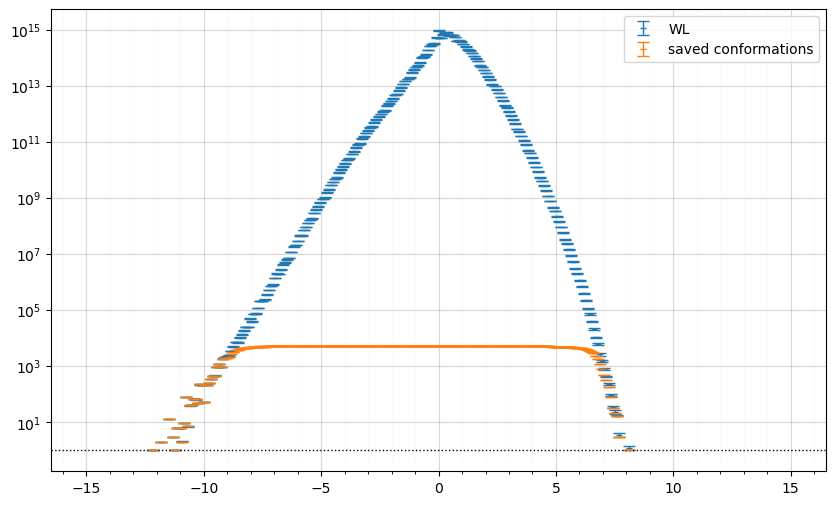

In [117]:
fig,ax=plt.subplots(figsize=(10,6))
ax.grid(alpha=0.5, which='both')
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=1)
ax.minorticks_on()
ax.set_axisbelow(True)

ax.errorbar(energy_bin_centers, mean_g_E, 
        yerr=std_g_E, fmt='_', markersize=5.0, markeredgewidth=1.0, capsize=4.0, 
        elinewidth=1.0,errorevery=1,label=f"WL")

ax.errorbar(energy_bin_centers, all_unique_saved_conformations_numbers, 
        yerr=0, fmt='_', markersize=5.0, markeredgewidth=1.0, capsize=4.0, 
        elinewidth=1.0,errorevery=1,label=f"saved conformations")


ax.axhline(1,c='k',lw=1.0,ls=':')
ax.legend()
ax.set_yscale('log')



In [118]:
@njit
def calculate_GE_of_conformation(conformation, contacts):
    N = len(conformation) + 1

    # prepare empty output in case there is no loop
    loop_indexes = -1*np.ones((1,2),dtype=np.int64)
    Nter_threads = -1*np.ones((1),dtype=np.int64)
    Cter_threads = -1*np.ones((1),dtype=np.int64)
    Nter_GE = np.nan*np.ones((1))
    Cter_GE = np.nan*np.ones((1))
    there_is_at_least_a_valid_loop=False


    # check if contacts give raise to valid loops
    tmp_loops = []
    for i_loop in range(len(contacts)):
        if contacts[i_loop, 0] > 0:     # check if contacts are valid (only for direct fortran output reason)
            if contacts[i_loop, 1] - contacts[i_loop, 0] > 6: # check if loop is long enough
                tmp_loops.append([contacts[i_loop, 0]-1, contacts[i_loop, 1]-1])

    if len(tmp_loops)>0:
        loop_indexes = np.array(tmp_loops, dtype=np.int64)
        n_tmp_loops = len(loop_indexes)
        
        # Calculate thread indices
        Nter_threads = np.zeros(n_tmp_loops, dtype=np.int64)
        Cter_threads = np.zeros(n_tmp_loops, dtype=np.int64)
        
        for i_loop in range(n_tmp_loops):
            if loop_indexes[i_loop, 0] > 3:
                Nter_threads[i_loop] = loop_indexes[i_loop, 0] - 2 # check if minimal (0-1-2) N-thread is present
            if loop_indexes[i_loop, 1] < (N - 4):
                Cter_threads[i_loop] = loop_indexes[i_loop, 1] + 2 # check if minimal ((N-3)-(N-2)-(N-1)) C-thread is present

        # Check if loops have at least one thread
        keep_mask = np.zeros(n_tmp_loops, dtype=np.bool_)
        for i_loop in range(n_tmp_loops):
            if not (Nter_threads[i_loop] == 0 and Cter_threads[i_loop] == 0):
                keep_mask[i_loop] = True
        
        # Apply the mask to all arrays at once
        loop_indexes = loop_indexes[keep_mask]
        Nter_threads = Nter_threads[keep_mask]
        Cter_threads = Cter_threads[keep_mask]
        
        n_loops = len(loop_indexes)
        Nter_GE = np.full(n_loops, np.nan, dtype=np.float64)
        Cter_GE = np.full(n_loops, np.nan, dtype=np.float64)
        
        

        if n_loops > 0:
            there_is_at_least_a_valid_loop=True

            #perform actual GE calculation
            bonds_conv = np.array([
                [-1.0, 0.0, 0.0], [1.0, 0.0, 0.0],
                [0.0, -1.0, 0.0], [0.0, 1.0, 0.0],
                [0.0, 0.0, -1.0], [0.0, 0.0, 1.0],
            ])

            pos_aa = np.zeros((N, 3))
            for i_aa in range(1, N):
                pos_aa[i_aa, :] = pos_aa[i_aa-1, :] + bonds_conv[conformation[i_aa-1]-1, :]
            
            pos_bv = 0.5 * (pos_aa[1:] + pos_aa[:-1])
            bv = np.zeros((N-1, 3))
            for i_bv in range(N-1):
                bv[i_bv, :] = bonds_conv[conformation[i_bv]-1, :]

            for i_loop in range(n_loops):
                


                # N-terminal GE
                if Nter_threads[i_loop] > 0:
                    sum_n = 0.0
                    for ii in range(Nter_threads[i_loop]):
                        for jj in range(loop_indexes[i_loop, 0], loop_indexes[i_loop, 1]):
                            # print('N',n_loops,loop_indexes.shape,Nter_threads[i_loop],Cter_threads[i_loop],ii,jj)
                            Ri__Rj = pos_bv[ii] - pos_bv[jj]
                            dist_sq = (Ri__Rj**2).sum()
                            # if dist_sq > 1e-9: # Avoid division by zero
                            cross = np.cross(bv[ii], bv[jj])
                            sum_n += np.dot(Ri__Rj, cross) / (4 * np.pi * (dist_sq**1.5))
                    Nter_GE[i_loop] = sum_n
                
                # C-terminal GE
                if Cter_threads[i_loop] > 0:
                    sum_c = 0.0
                    for ii in range(Cter_threads[i_loop], N-1):
                        for jj in range(loop_indexes[i_loop, 0], loop_indexes[i_loop, 1]):
    #                         print('C', loop_indexes[i_loop, :],Cter_threads[i_loop], ii, jj)
    #                         print(f"""\
    # loop: {loop_indexes[i_loop, 0]}-{loop_indexes[i_loop, 1]} |\
    # C thread: {Cter_threads[i_loop]}-{(N-2)}| \
    # i = {jj}, jj = {ii} \
    # """)
    # 'C thread ', loop_indexes[i_loop, :],Cter_threads[i_loop], ii, jj)


                            Ri__Rj = pos_bv[ii] - pos_bv[jj]
                            dist_sq = (Ri__Rj**2).sum()
                            # if dist_sq > 1e-9:
                            cross = np.cross(bv[ii], bv[jj])
                            sum_c += np.dot(Ri__Rj, cross) / (4 * np.pi * (dist_sq**1.5))
                    Cter_GE[i_loop] = sum_c

    return loop_indexes, Nter_GE, Cter_GE, Nter_threads, Cter_threads,there_is_at_least_a_valid_loop


@njit
def return_contacts(conformation):

    # prepare empty output in case there is no contact in the chain
    contacts=np.zeros((1,2),dtype=np.int64)
    there_is_at_least_a_contact=False

    N = len(conformation)+1  # conformation is given as (N-1) bond vector numbers i_loop.e. numbers [1-6]
    bonds_conv=np.array([
        [-1.0, 0.0, 0.0],
        [1.0, 0.0, 0.0],
        [0.0, -1.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, -1.0],
        [0.0, 0.0, 1.0],
    ])

    pos_aa=np.zeros((N,3))
    for i_aa in range(1,N):
        pos_aa[i_aa,:]=pos_aa[i_aa-1,:]+bonds_conv[conformation[i_aa-1]-1,:]

    tmp_contacts=[]
    for ii in range(N-2):
        for jj in range(ii+3,N):
            DR_ij=pos_aa[jj,:]-pos_aa[ii,:]
            norm_DR_ij=(DR_ij**2).sum()
            if np.isclose(norm_DR_ij,1.0):
                tmp_contacts.append([ii+1,jj+1])
    if len(tmp_contacts)>0:
        contacts=np.array(tmp_contacts)
        there_is_at_least_a_contact=True

    return contacts, there_is_at_least_a_contact



all_bins_all_confs_max_abs_GE=[]
for i_bin in range(n_bins):
    all_bins_all_confs_max_abs_GE.append([])
    if all_unique_saved_conformations_numbers[i_bin]>0:
        for i_conf in range(len(all_unique_saved_conformations[i_bin])):
            now_conformation=all_unique_saved_conformations[i_bin][i_conf]
            now_contacts,there_is_at_least_a_contact=return_contacts(now_conformation)
            if there_is_at_least_a_contact:
                loop_indexes, Nter_GE, Cter_GE, Nter_threads_indexes, Cter_threads_indexes,there_is_at_least_a_valid_loop = \
                    calculate_GE_of_conformation(now_conformation,now_contacts)
                if there_is_at_least_a_valid_loop:
                    NC_GE=np.vstack((Nter_GE,Cter_GE))
                    all_bins_all_confs_max_abs_GE[-1].append(np.nanmax(np.abs(NC_GE)))
                
                


In [119]:
ave_max_abs_GE=np.ones((n_bins))*np.nan
std_max_abs_GE=np.ones((n_bins))*np.nan
max_max_abs_GE=np.ones((n_bins))*np.nan
min_max_abs_GE=np.ones((n_bins))*np.nan
for i_bin in range(n_bins):
    if len(all_bins_all_confs_max_abs_GE[i_bin])>0:
        ave_max_abs_GE[i_bin]=np.array(all_bins_all_confs_max_abs_GE[i_bin]).mean()
        std_max_abs_GE[i_bin]=np.array(all_bins_all_confs_max_abs_GE[i_bin]).std()
        max_max_abs_GE[i_bin]=np.array(all_bins_all_confs_max_abs_GE[i_bin]).max()
        min_max_abs_GE[i_bin]=np.array(all_bins_all_confs_max_abs_GE[i_bin]).min()

Text(0, 0.5, "$\\langle \\max|G'|\\rangle$")

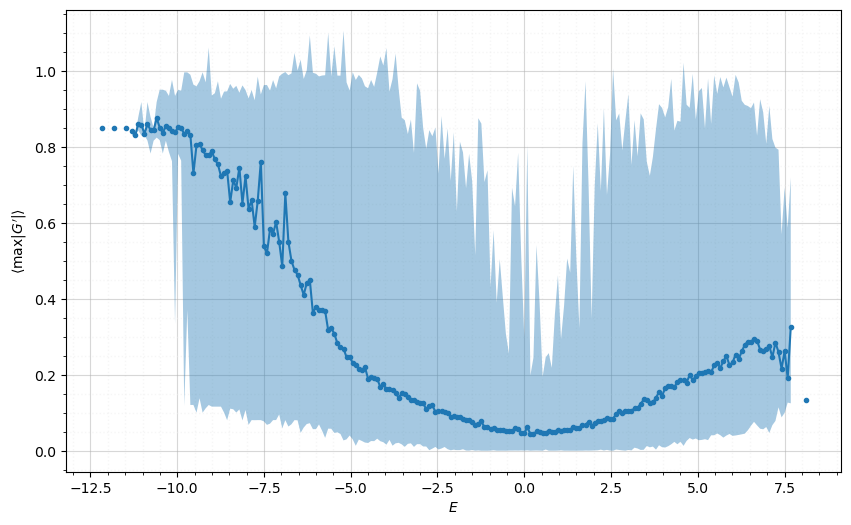

In [120]:
fig,ax=plt.subplots(figsize=(10,6))
ax.grid(alpha=0.5, which='both')
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=1)
ax.minorticks_on()
ax.set_axisbelow(True)

ax.plot(energy_bin_centers,ave_max_abs_GE,'.-')
# ax.fill_between(
#     energy_bin_centers,
#     ave_max_abs_GE+std_max_abs_GE,
#     ave_max_abs_GE-std_max_abs_GE,
#     color=ax.lines[-1].get_color(),
#     alpha=0.4,
#     lw=0.0,
# )

ax.fill_between(
    energy_bin_centers,
    max_max_abs_GE,
    min_max_abs_GE,
    color=ax.lines[-1].get_color(),
    alpha=0.4,
    lw=0.0,
)

ax.set_xlabel('$E$')
ax.set_ylabel("$\langle \max|G'|\\rangle$")


In [121]:
comparison_conformation=np.array([1, 3, 1, 4, 4, 1, 3, 3, 5, 4, 4, 2 ,3 ,5 ,2, 3, 1, 6, 2, 4, 4, 5, 1, 1, 1, 5],dtype=np.int64)
comparison_contacts,there_is_at_least_a_contact=return_contacts(comparison_conformation)
loop_indexes, Nter_GE, Cter_GE, Nter_threads_indexes, Cter_threads_indexes,there_is_at_least_a_valid_loop = \
    calculate_GE_of_conformation(comparison_conformation,comparison_contacts)


print('for the conformation:')
for bond in comparison_conformation:
    print(f"{bond:} ",end='')
print()
print('I get:')
for ii in range(len(loop_indexes)):
    print(f"""\
loop: {loop_indexes[ii][0]:>2} - {loop_indexes[ii][1]:>2} \t\
G_N: {Nter_GE[ii]:>8.3f} \t\
G_C: {Cter_GE[ii]:>8.3f} \
""")

for the conformation:
1 3 1 4 4 1 3 3 5 4 4 2 3 5 2 3 1 6 2 4 4 5 1 1 1 5 
I get:
loop:  1 - 20 	G_N:      nan 	G_C:   -0.056 
loop:  2 - 19 	G_N:      nan 	G_C:   -0.104 
loop:  3 - 18 	G_N:      nan 	G_C:   -0.180 
loop:  4 - 13 	G_N:    0.023 	G_C:   -0.122 
loop:  5 - 12 	G_N:   -0.007 	G_C:   -0.024 
loop:  9 - 18 	G_N:    0.026 	G_C:   -0.133 
loop: 11 - 24 	G_N:   -0.014 	G_C:      nan 
loop: 12 - 21 	G_N:   -0.039 	G_C:   -0.058 
loop: 12 - 23 	G_N:   -0.005 	G_C:      nan 
loop: 13 - 20 	G_N:   -0.017 	G_C:   -0.036 
loop: 14 - 23 	G_N:   -0.128 	G_C:      nan 
loop: 15 - 22 	G_N:   -0.181 	G_C:    0.012 
